In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from wordcloud import WordCloud

In [2]:
categories = [
    'sci.space',
    'sci.med',
    'comp.graphics',
    'rec.sport.hockey',
    'talk.politics.guns'
]

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print(f"Total documents: {len(newsgroups.data)}")
print(f"Categories: {newsgroups.target_names}")
print(f"\nExample text:\n{newsgroups.data[0][:300]}")

Total documents: 4859
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']

Example text:
Hi Folks,

   Does anyone have a copy of Playmation they'd be willing to sell me.  I'd 
love to try it out, but not for the retail $$$.  If you have moved onto 
something bigger (3DS) or better (Imagine), I'd love to buy your table scraps.

   If noone is selling, can anyone recommend a place to buy


In [3]:
import re

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to all documents
cleaned_texts = [preprocess(doc) for doc in newsgroups.data]

# Show before and after
print("BEFORE:")
print(newsgroups.data[0][:300])
print("\nAFTER:")
print(cleaned_texts[0][:300])

BEFORE:
Hi Folks,

   Does anyone have a copy of Playmation they'd be willing to sell me.  I'd 
love to try it out, but not for the retail $$$.  If you have moved onto 
something bigger (3DS) or better (Imagine), I'd love to buy your table scraps.

   If noone is selling, can anyone recommend a place to buy

AFTER:
hi folks does anyone have a copy of playmation theyd be willing to sell me id love to try it out but not for the retail if you have moved onto something bigger ds or better imagine id love to buy your table scraps if noone is selling can anyone recommend a place to buy playmation mailorder for cheap


In [5]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_texts,
    newsgroups.target,
    test_size=0.2,
    random_state=42
)

print(f"Training documents: {len(X_train)}")
print(f"Testing documents: {len(X_test)}")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    stop_words='english', # removes common words like 'the', 'a', 'is'
    max_features=10000, # keep only top 10,000 words
    ngram_range=(1, 2) # use single words AND pairs (e.g. 'ice hockey')
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nVocabulary size: {len(tfidf.vocabulary_)}")
print(f"Training matrix shape: {X_train_tfidf.shape}")

Training documents: 3887
Testing documents:  972

Vocabulary size: 10000
Training matrix shape: (3887, 10000)


In [7]:
# Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB(alpha=1.0) # alpha is smoothing to handle unseen words
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)

print("Both models trained successfully!")
print(f"\nNaive Bayes Accuracy: {accuracy_score(y_test, nb_predictions):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")

Both models trained successfully!

Naive Bayes Accuracy: 0.8807
Logistic Regression Accuracy: 0.8714


In [10]:
category_names = ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']

print("NAIVE BAYES Full Report")
print(classification_report(y_test, nb_predictions, target_names=category_names))

print("LOGISTIC REGRESSION Full Report")
print(classification_report(y_test, lr_predictions, target_names=category_names))

NAIVE BAYES Full Report
                    precision    recall  f1-score   support

     comp.graphics       0.84      0.92      0.88       195
  rec.sport.hockey       0.81      0.97      0.88       173
           sci.med       0.93      0.84      0.89       197
         sci.space       0.91      0.80      0.85       201
talk.politics.guns       0.92      0.89      0.90       206

          accuracy                           0.88       972
         macro avg       0.88      0.88      0.88       972
      weighted avg       0.89      0.88      0.88       972

LOGISTIC REGRESSION Full Report
                    precision    recall  f1-score   support

     comp.graphics       0.87      0.88      0.88       195
  rec.sport.hockey       0.95      0.94      0.94       173
           sci.med       0.86      0.84      0.85       197
         sci.space       0.79      0.84      0.81       201
talk.politics.guns       0.90      0.86      0.88       206

          accuracy                     

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_predictions = rf_model.predict(X_test_tfidf)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print()

print("RANDOM FOREST Full Report")
print(classification_report(y_test, rf_predictions, target_names=category_names))

Random Forest Accuracy: 0.7994

RANDOM FOREST Full Report
                    precision    recall  f1-score   support

     comp.graphics       0.73      0.85      0.78       195
  rec.sport.hockey       0.89      0.92      0.91       173
           sci.med       0.75      0.77      0.76       197
         sci.space       0.79      0.73      0.76       201
talk.politics.guns       0.87      0.75      0.81       206

          accuracy                           0.80       972
         macro avg       0.80      0.80      0.80       972
      weighted avg       0.80      0.80      0.80       972



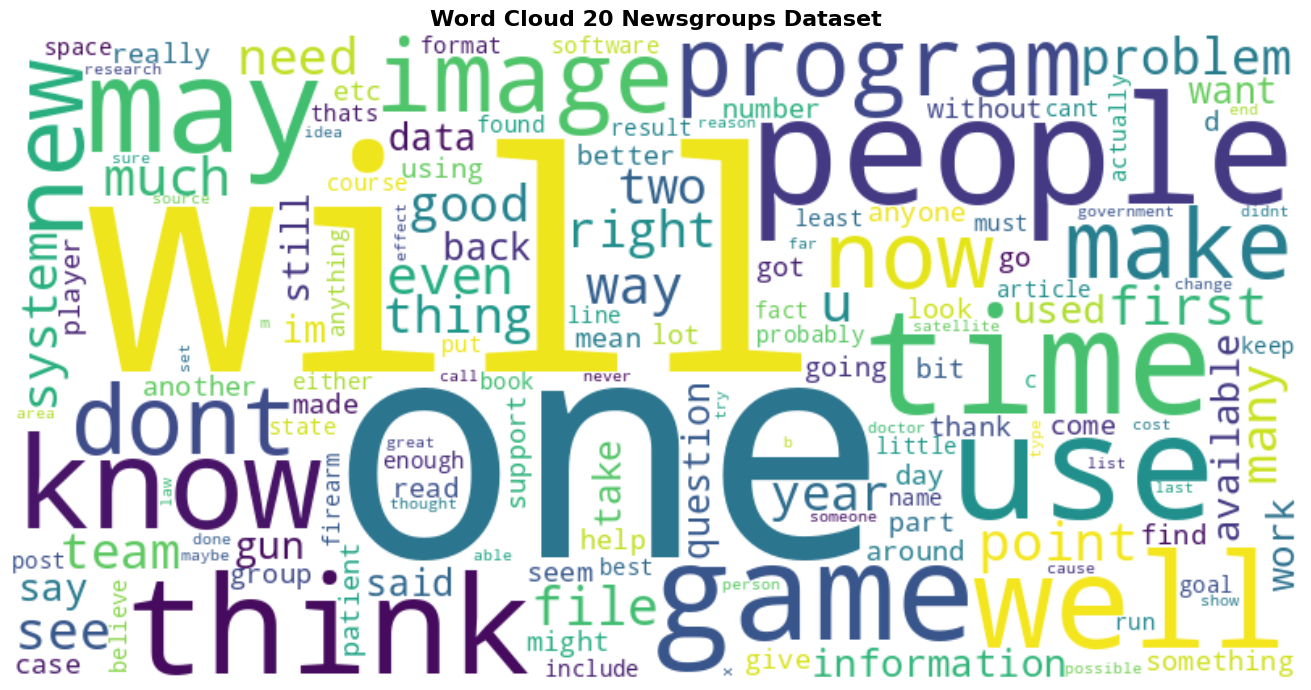

Word cloud saved as wordcloud.png


In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned texts into one big string
all_text = ' '.join(cleaned_texts)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=150,
    colormap='viridis'
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud 20 Newsgroups Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

print("Word cloud saved as wordcloud.png")

In [14]:
category_names = ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']

example_texts = [
    "The astronauts on the space shuttle performed a successful orbit around Earth.",
    "The patient was diagnosed with a rare neurological disease affecting the brain.",
    "The hockey team scored three goals in the final period to win the championship.",
    "I need help rendering 3D images using OpenGL on my graphics card.",
    "The government should enforce stricter background checks for firearm purchases."
]

print("EXAMPLE PREDICTIONS")
for text in example_texts:
    cleaned = preprocess(text)
    vectorized = tfidf.transform([cleaned])

    nb_pred = category_names[nb_model.predict(vectorized)[0]]
    lr_pred = category_names[lr_model.predict(vectorized)[0]]
    rf_pred = category_names[rf_model.predict(vectorized)[0]]

    print(f"\nText: {text}")
    print(f"Naive Bayes: {nb_pred}")
    print(f"Logistic Regression:{lr_pred}")
    print(f"Random Forest: {rf_pred}")

EXAMPLE PREDICTIONS

Text: The astronauts on the space shuttle performed a successful orbit around Earth.
Naive Bayes: sci.space
Logistic Regression:sci.space
Random Forest: sci.space

Text: The patient was diagnosed with a rare neurological disease affecting the brain.
Naive Bayes: sci.med
Logistic Regression:sci.med
Random Forest: sci.med

Text: The hockey team scored three goals in the final period to win the championship.
Naive Bayes: rec.sport.hockey
Logistic Regression:rec.sport.hockey
Random Forest: rec.sport.hockey

Text: I need help rendering 3D images using OpenGL on my graphics card.
Naive Bayes: comp.graphics
Logistic Regression:comp.graphics
Random Forest: comp.graphics

Text: The government should enforce stricter background checks for firearm purchases.
Naive Bayes: talk.politics.guns
Logistic Regression:talk.politics.guns
Random Forest: talk.politics.guns


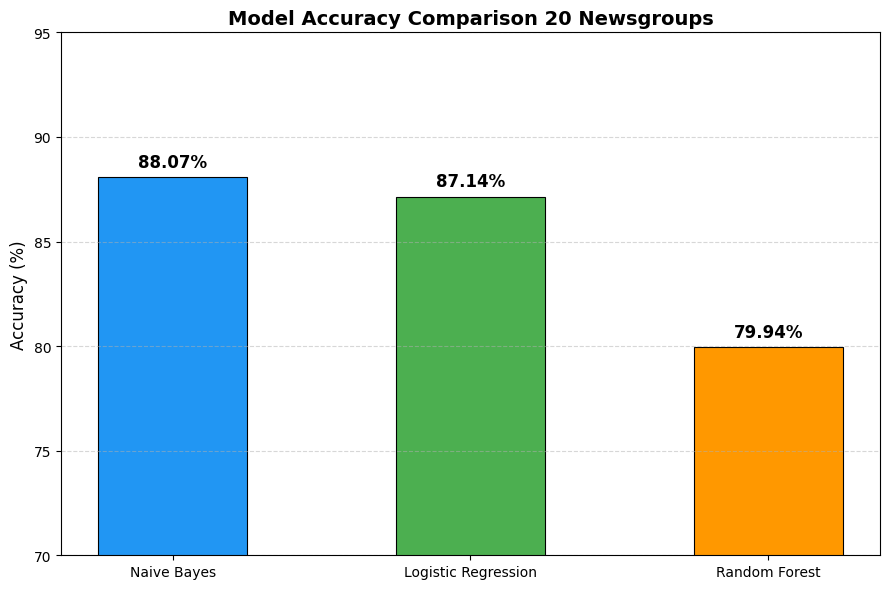

Chart saved as accuracy_chart.png


In [16]:
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies = [
    accuracy_score(y_test, nb_predictions) * 100,
    accuracy_score(y_test, lr_predictions) * 100,
    accuracy_score(y_test, rf_predictions) * 100
]
colors = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(9, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Accuracy Comparison 20 Newsgroups', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(70, 95)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as accuracy_chart.png")